## 準備

In [1]:
import networkx as nx
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import Planetoid
from torch_geometric.utils.convert import (
    to_networkx,
    from_networkx
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/home/njz/study_graph/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Planetoid(root="./dataset", name="PubMed")
G = to_networkx(dataset.data, to_undirected=True)

/tmp/ipykernel_45461/906208631.py:2: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  G = to_networkx(dataset.data, to_undirected=True)


## ネットワーク全体の概形を見る

In [3]:
print("大きさ（ノード数）: ", G.number_of_nodes())
print("エッジの数: ", G.number_of_edges())

大きさ（ノード数）:  19717
エッジの数:  44324


In [4]:
print("密度: ", nx.density(G))

密度:  0.00022803908825811382


In [5]:
# 愚直に算出する場合
print(
    "密度（愚直に算出）: ",
    (G.number_of_edges() * 2 / (G.number_of_nodes() * (G.number_of_nodes() - 1))),
)

密度（愚直に算出）:  0.00022803908825811382


In [6]:
if False: # 計算に時間がかかる
    print("直径: ", nx.diameter(G))

そもそも連結なんですか？

In [7]:
print("連結しているか: ", nx.is_connected(G))
print("連結成分の数: ", nx.number_connected_components(G))

連結しているか:  True
連結成分の数:  1


In [8]:
# 各連結成分を構成するノード集合
components = nx.connected_components(G)
print(f"{components=}")
# 最大連結成分のノード集合
nodes_largest_component = max(components, key=len)
print(f"{nodes_largest_component=}")
# 最大連結成分を部分グラフとして取得
subg = G.subgraph(nodes_largest_component).copy()
print(f"{subg=}")

components=<generator object connected_components at 0x7dc636df1a80>


nodes_largest_component={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 

In [9]:
print("最大連結成分の大きさ: ", subg.number_of_nodes())
print("最大連結成分の大きさ: ", len(subg))

最大連結成分の大きさ:  19717
最大連結成分の大きさ:  19717


## 個々のノードについての特徴

### 次数中心性

In [10]:
degree_c = G.degree()
print(degree_c)

[(0, 5), (1, 3), (2, 3), (3, 1), (4, 1), (5, 2), (6, 22), (7, 17), (8, 1), (9, 9), (10, 6), (11, 1), (12, 10), (13, 1), (14, 1), (15, 6), (16, 29), (17, 6), (18, 8), (19, 8), (20, 1), (21, 2), (22, 2), (23, 1), (24, 4), (25, 1), (26, 5), (27, 3), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 3), (35, 17), (36, 1), (37, 1), (38, 4), (39, 1), (40, 8), (41, 4), (42, 1), (43, 1), (44, 1), (45, 1), (46, 11), (47, 31), (48, 18), (49, 2), (50, 1), (51, 1), (52, 1), (53, 1), (54, 6), (55, 2), (56, 1), (57, 3), (58, 7), (59, 3), (60, 25), (61, 1), (62, 22), (63, 1), (64, 2), (65, 3), (66, 1), (67, 2), (68, 1), (69, 7), (70, 1), (71, 3), (72, 5), (73, 1), (74, 1), (75, 1), (76, 3), (77, 9), (78, 1), (79, 2), (80, 3), (81, 2), (82, 1), (83, 2), (84, 3), (85, 7), (86, 6), (87, 1), (88, 14), (89, 1), (90, 1), (91, 2), (92, 1), (93, 1), (94, 1), (95, 4), (96, 1), (97, 2), (98, 1), (99, 13), (100, 2), (101, 19), (102, 3), (103, 2), (104, 1), (105, 15), (106, 1), (107, 1), (108, 5), (109,

In [11]:
df_degree = pd.DataFrame(
    list(degree_c),
    columns=["node_id", "degree"],
)
df_degree

,node_id,degree
0,0,5
1,1,3
2,2,3
3,3,1
4,4,1
...,...,...
19712,19712,1
19713,19713,1
19714,19714,1
19715,19715,1


### 固有ベクトル中心性

In [12]:
eigen_c = nx.eigenvector_centrality(G)
print(eigen_c)
print("len(eigen_c): ", len(eigen_c))

{0: 0.00023434854228360225, 1: 1.961610489750726e-06, 2: 2.4244205161309935e-05, 3: 0.00024243768339282228, 4: 3.744676658921824e-07, 5: 0.00023448359061203593, 6: 0.02154640900674408, 7: 0.00013234787968180467, 8: 3.291732420569048e-05, 9: 3.6524288458446106e-05, 10: 2.09118979793262e-05, 11: 1.8290923316399146e-05, 12: 1.8887425699229357e-05, 13: 0.004616037207048904, 14: 0.0003980736978936708, 15: 5.935071149979517e-06, 16: 2.374399360057192e-06, 17: 2.8382672785353804e-06, 18: 0.000284483071712182, 19: 0.0016893741721596776, 20: 4.5556756459328576e-05, 21: 2.3618067152352315e-06, 22: 0.0016825684639215673, 23: 8.453110557522946e-07, 24: 0.002732652325163355, 25: 1.3841872854354556e-06, 26: 4.141951365018733e-08, 27: 7.215460253614558e-06, 28: 2.175114006801188e-06, 29: 2.1565973894985792e-05, 30: 4.8698567939830826e-06, 31: 1.4424472523836409e-05, 32: 2.427879803777681e-06, 33: 1.336315423459657e-06, 34: 5.056186237659934e-06, 35: 7.635564991173865e-06, 36: 3.3313844296011327e-06, 

### 近接中心性

In [13]:
if False: # 計算に時間がかかる
    closeness_c = nx.closeness_centrality(G)
    print(closeness_c)

### 媒介中心性

In [14]:
if False: # 計算に時間がかかる
    betweenness_c = nx.betweenness_centrality(G)
    print(betweenness_c)

### ページランク

In [15]:
if False: # 計算に時間がかかる
    pagerank_c = nx.pagerank(G)
    print(pagerank_c)

### 局所クラスター係数

In [16]:
if False: # 計算に時間がかかる
    local_clustering = nx.clustering(G)
    print(local_clustering)

### 最短経路

In [17]:
# ダイクストラ法より
print(nx.shortest_path(G, source=0, target=1, method="dijkstra"))

# すべての最短経路
print(
    [path for path in nx.all_shortest_paths(G, source=0, target=1, method="dijkstra")]
)

[0, 1544, 2110, 7780, 5966, 2943, 1]
[[0, 1544, 2110, 7780, 5966, 2943, 1], [0, 6092, 7191, 15864, 13705, 8359, 1], [0, 6092, 16772, 11449, 10051, 8359, 1], [0, 14442, 8372, 6039, 10487, 8359, 1]]


## ネットワーク全体をみる

### 次数分布

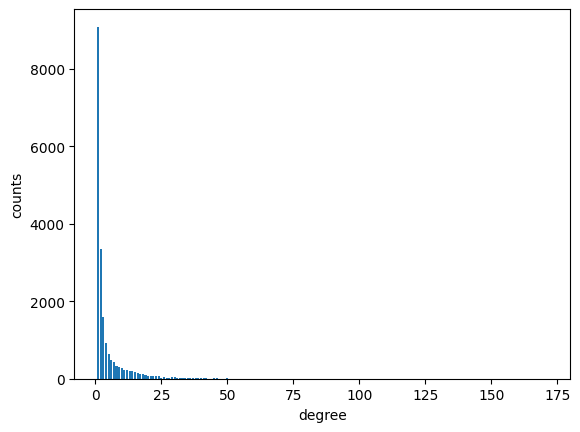

In [ ]:
degree_sequence = sorted(
    (d for n, d in G.degree()),
    reverse=True,
)
plt.bar(*np.unique(degree_sequence, return_counts=True))
plt.xlabel("degree")
plt.ylabel("counts")
plt.show()

In [20]:
degree_sequence

[171,
 154,
 131,
 130,
 125,
 121,
 88,
 83,
 80,
 77,
 77,
 75,
 75,
 74,
 74,
 74,
 73,
 73,
 72,
 72,
 69,
 68,
 67,
 67,
 67,
 66,
 66,
 64,
 63,
 62,
 62,
 61,
 61,
 60,
 60,
 59,
 59,
 59,
 59,
 58,
 58,
 58,
 58,
 57,
 57,
 57,
 56,
 56,
 56,
 55,
 55,
 55,
 54,
 54,
 53,
 53,
 53,
 52,
 52,
 52,
 52,
 51,
 51,
 51,
 51,
 50,
 50,
 50,
 50,
 50,
 50,
 50,
 49,
 49,
 48,
 48,
 48,
 47,
 47,
 47,
 47,
 47,
 46,
 46,
 46,
 46,
 46,
 46,
 46,
 46,
 46,
 46,
 45,
 45,
 45,
 45,
 45,
 45,
 45,
 44,
 44,
 44,
 44,
 44,
 43,
 42,
 42,
 42,
 42,
 42,
 42,
 42,
 42,
 42,
 42,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 41,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 40,
 39,
 39,
 39,
 39,
 39,
 39,
 39,
 39,
 39,
 39,
 38,
 38,
 38,
 38,
 38,
 38,
 38,
 38,
 38,
 38,
 38,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 37,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 36,
 35,
 35,
 35,
 35,

In [22]:
np.unique(degree_sequence, return_counts=True)

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  66,
         67,  68,  69,  72,  73,  74,  75,  77,  80,  83,  88, 121, 125,
        130, 131, 154, 171]),
 array([9094, 3357, 1584,  914,  642,  491,  423,  316,  303,  265,  229,
         227,  193,  192,  167,  135,  133,  117,   98,   74,   77,   72,
          68,   62,   31,   35,   23,   31,   33,   39,   24,   18,   20,
          16,   19,   20,   15,   11,   10,   12,   12,   10,    1,    5,
           7,   10,    5,    3,    2,    7,    4,    4,    3,    2,    3,
           3,    3,    4,    4,    2,    2,    2,    1,    1,    2,    3,
           1,    1,    2,    2,    3,    2,    2,    1,    1,    1,    1,
           1, 

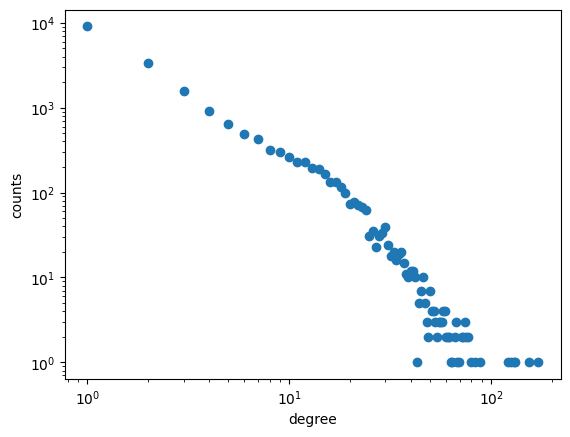

In [23]:
plt.scatter(*np.unique(degree_sequence, return_counts=True))
plt.xlabel("degree")
plt.ylabel("counts")
plt.xscale("log")
plt.yscale("log")
plt.show()

### 次数相関

In [24]:
print("次数相関: ", nx.degree_pearson_correlation_coefficient(G))

次数相関:  -0.043640315703345395


### 大域的クラスター係数

In [25]:
print("大域的クラスター係数: ", nx.transitivity(G))

大域的クラスター係数:  0.0537076280274887
